### Extracting Resistance_genes, Pathogens, Resistance mechanisms, Antibiotics data from [CARD](https://card.mcmaster.ca/prevalence): AMR Layer

In [1]:
import pandas as pd
import numpy as np

In [2]:
#Import data, quick peep
data_amr = pd.read_csv('card-prevalence/card_prevalence.csv')

data_amr.tail(3)

,ARO_Accession,Name,Model_ID,Model_Type,Pathogen,NCBI_Plasmid,NCBI_WGS,NCBI_Chromosome,NCBI_Genomic_Island,Criteria,...,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26
20038,ARO:3007473,Mycobacterium avium gyrA with mutation conferr...,5956,protein variant model,Corynebacterium ulcerans,0.0,4.55,0.00,0.0,perfect_strict,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20039,ARO:3007473,Mycobacterium avium gyrA with mutation conferr...,5956,protein variant model,Corynebacterium amycolatum,0.0,3.70,14.29,0.0,perfect_strict,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20040,ARO:3007473,Mycobacterium avium gyrA with mutation conferr...,5956,protein variant model,Corynebacterium jeikeium,0.0,0.00,40.00,0.0,perfect_strict,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
#Gathering antibiotic columns since they are unnamed due to the original document set up and conversion
unnamed_cols = [data_amr.columns[a] for a in range(len(data_amr.columns)) if 'Unnamed' in data_amr.columns[a]]

In [4]:
#Creating a column with Antibiotics by merging all columns, ignoring NaNs, seperated by ','
data_amr['Drug_Class'] = data_amr[unnamed_cols].apply(lambda x: ','.join(x.dropna()),axis = 1)
data_amr.drop(unnamed_cols, axis = 1, inplace = True)

In [5]:
data_amr.tail(3)

,ARO_Accession,Name,Model_ID,Model_Type,Pathogen,NCBI_Plasmid,NCBI_WGS,NCBI_Chromosome,NCBI_Genomic_Island,Criteria,ARO_Categories,Drug_Class
20038,ARO:3007473,Mycobacterium avium gyrA with mutation conferr...,5956,protein variant model,Corynebacterium ulcerans,0.0,4.55,0.00,0.0,perfect_strict,antibiotic target alteration,"fluoroquinolone antibiotic, nybomycin-like an..."
20039,ARO:3007473,Mycobacterium avium gyrA with mutation conferr...,5956,protein variant model,Corynebacterium amycolatum,0.0,3.70,14.29,0.0,perfect_strict,antibiotic target alteration,"fluoroquinolone antibiotic, nybomycin-like an..."
20040,ARO:3007473,Mycobacterium avium gyrA with mutation conferr...,5956,protein variant model,Corynebacterium jeikeium,0.0,0.00,40.00,0.0,perfect_strict,antibiotic target alteration,"fluoroquinolone antibiotic, nybomycin-like an..."


In [6]:
data_amr.rename(columns = {'ARO_Categories':'Resistance_Mechanism', 'Name':'Resistance_Gene'}, inplace = True)

#Dropping (what I believe are) irrelevant columns
data_amr.drop(['Model_ID', 'Model_Type', 'NCBI_Plasmid', 'NCBI_WGS', 'NCBI_Chromosome', 'NCBI_Genomic_Island', 'Criteria'], axis = 1, inplace = True) 

In [7]:
data_amr.tail(3)

,ARO_Accession,Resistance_Gene,Pathogen,Resistance_Mechanism,Drug_Class
20038,ARO:3007473,Mycobacterium avium gyrA with mutation conferr...,Corynebacterium ulcerans,antibiotic target alteration,"fluoroquinolone antibiotic, nybomycin-like an..."
20039,ARO:3007473,Mycobacterium avium gyrA with mutation conferr...,Corynebacterium amycolatum,antibiotic target alteration,"fluoroquinolone antibiotic, nybomycin-like an..."
20040,ARO:3007473,Mycobacterium avium gyrA with mutation conferr...,Corynebacterium jeikeium,antibiotic target alteration,"fluoroquinolone antibiotic, nybomycin-like an..."


Pathogens of interest

Core: Klebsiella pneumoniae, Streptococcus pneumoniae, Escherichia coli, Acinetobacter baumannii, Mycobacterium tuberculosis 

Extended: Enterococcus faecalis, Staphylococcus aureus, Pseudomonas aeruginosa, Burkholderia pseudomallei, Porphyromonas gingivalis

In [8]:
pathogens_of_interest = ['Klebsiella pneumoniae', 'Streptococcus pneumoniae', 'Escherichia coli', 'Acinetobacter baumannii', 'Mycobacterium tuberculosis', 'Enterococcus faecalis', 'Staphylococcus aureus', 'Pseudomonas aeruginosa','Burkholderia pseudomallei','Porphyromonas gingivalis']

In [9]:
#Creating unique IDs for the pathogens
id = ['B']*len(pathogens_of_interest)
id2 = np.array(range(10)).astype(str)
pathogen_ids = id + id2
pathogen_data = pd.DataFrame({'Pathogen':pathogens_of_interest, 'p_ID': pathogen_ids})
pathogen_data

,Pathogen,p_ID
0,Klebsiella pneumoniae,B0
1,Streptococcus pneumoniae,B1
2,Escherichia coli,B2
3,Acinetobacter baumannii,B3
4,Mycobacterium tuberculosis,B4
5,Enterococcus faecalis,B5
6,Staphylococcus aureus,B6
7,Pseudomonas aeruginosa,B7
8,Burkholderia pseudomallei,B8
9,Porphyromonas gingivalis,B9


In [10]:
pathogen_data.to_csv(r'pathogen_data_15_07.csv')

In [11]:
data_amr_poi = data_amr[data_amr['Pathogen'].isin(pathogens_of_interest)]

In [12]:
#Function for splitting up comma seperated lists in Resistance_Mechanism and Drug_Class columns
def split_multiple_entries(df,column_of_interest):
    for j in range(len(df)):
        list_split = df.loc[j,column_of_interest].split(',')
        
        df.loc[j,column_of_interest] = list_split[0]
        if (len(list_split) > 1) & (column_of_interest == 'Resistance_Mechanism'):
            add_ons = pd.DataFrame({'ARO_Accession':[df.loc[j,'ARO_Accession']]*(len(list_split)-1),'Resistance_Gene':[df.loc[j,'Resistance_Gene']]*(len(list_split)-1), 'Pathogen':[df.loc[j,'Pathogen']]*(len(list_split)-1), 'Resistance_Mechanism': list_split[1:len(list_split)], 'Drug_Class':[df.loc[j,'Drug_Class']]*(len(list_split)-1)})

            df = pd.concat([df,add_ons],ignore_index= True)

        if (len(list_split) > 1) & (column_of_interest == 'Drug_Class'):
            add_ons = pd.DataFrame({'ARO_Accession':[df.loc[j,'ARO_Accession']]*(len(list_split)-1),'Resistance_Gene':[df.loc[j,'Resistance_Gene']]*(len(list_split)-1), 'Pathogen':[df.loc[j,'Pathogen']]*(len(list_split)-1), 'Resistance_Mechanism': [df.loc[j,'Resistance_Mechanism']]*(len(list_split)-1), 'Drug_Class': list_split[1:len(list_split)]})

            df = pd.concat([df,add_ons],ignore_index= True)

            
    return df 

In [13]:
# quick test of function
# for_test = data_amr_poi[data_amr_poi['Pathogen'] == 'Klebsiella pneumoniae'].tail(5).reset_index(drop=True)
# split_multiple_entries(for_test,'Drug_Class')

In [14]:
data_amr_poi1 = split_multiple_entries(data_amr_poi.reset_index(drop=True),'Drug_Class')
data_amr_poi2 = split_multiple_entries(data_amr_poi1,'Resistance_Mechanism')

In [15]:
#Some more data formatting/cleaning 
data_amr_poi2['Drug_Class'] = data_amr_poi2['Drug_Class'].str.replace('antibiotic','')
data_amr_poi2['Drug_Class'] = data_amr_poi2['Drug_Class'].str.replace(' ','')
data_amr_poi2['Drug_Class'] = data_amr_poi2['Drug_Class'].replace({'disinfectingagentsandantiseptics':'disinfecting agents and antiseptics','streptograminA':'streptogramin A',
                                                                   'streptograminB':'streptogramin B', 'salicylicacid':'salicylic acid','phosphonicacid':'phosphonic acid'}, regex = True)


In [16]:
data_amr_poi2.head(3)

,ARO_Accession,Resistance_Gene,Pathogen,Resistance_Mechanism,Drug_Class
0,ARO:3003390,Escherichia coli ompF with mutation conferring...,Escherichia coli,reduced permeability to antibiotic,carbapenem
1,ARO:3001109,SHV-52,Klebsiella pneumoniae,antibiotic inactivation,carbapenem
2,ARO:3001109,SHV-52,Klebsiella pneumoniae,antibiotic inactivation,carbapenem


Building dataframe of the form  [sourceID, source, source_type, relation, display relation, targetID, target, target_type]

In [17]:
# Confirming uniqueness of ARO_accession number 
len(data_amr_poi2['Resistance_Gene'].unique()) == len(data_amr_poi2['ARO_Accession'].unique())

True

In [18]:
# Creating Resistance_Gene node dataframe
Resistance_Gene_data = data_amr_poi2[['ARO_Accession', 'Resistance_Gene']].groupby(data_amr_poi2['ARO_Accession']).first().reset_index(drop = True)
Resistance_Gene_data.head()

,ARO_Accession,Resistance_Gene
0,ARO:3000005,vanD
1,ARO:3000010,vanA
2,ARO:3000013,vanB
3,ARO:3000024,patA
4,ARO:3000025,patB


In [19]:
# Creating resistant_mechanism node dataframe
r_ids = ['R']*len(data_amr_poi2['Resistance_Mechanism'].unique()) + np.array(range(len(data_amr_poi2['Resistance_Mechanism'].unique()))).astype(str)
resistance_mech_data = pd.DataFrame({'Resistance_Mechanism':data_amr_poi2['Resistance_Mechanism'].unique(), 'mech_ID': r_ids})
resistance_mech_data.head()

,Resistance_Mechanism,mech_ID
0,reduced permeability to antibiotic,R0
1,antibiotic inactivation,R1
2,antibiotic target replacement,R2
3,antibiotic efflux,R3
4,antibiotic target protection,R4


In [20]:
# Creating drug_class node dataframe
d_ids = ['D']*len(data_amr_poi2['Drug_Class'].unique()) + np.array(range(len(data_amr_poi2['Drug_Class'].unique()))).astype(str)
drug_data = pd.DataFrame({'Drug_Class':data_amr_poi2['Drug_Class'].unique(), 'drug_ID': d_ids})
drug_data.head()

,Drug_Class,drug_ID
0,carbapenem,D0
1,diaminopyrimidine,D1
2,cephalosporin,D2
3,tetracycline,D3
4,fusidane,D4


In [21]:
drug_data.to_csv(r'drug_data_14_07.csv', index = False)

In [22]:
#Initialising ID columns
data_amr_poi2['p_ID'] = np.zeros(len(data_amr_poi2))
data_amr_poi2['d_ID'] = np.zeros(len(data_amr_poi2))
data_amr_poi2['r_ID'] = np.zeros(len(data_amr_poi2))

In [23]:
pathogen_dict = {'Klebsiella pneumoniae':'B0', 'Streptococcus pneumoniae':'B1', 'Escherichia coli':'B2', 'Acinetobacter baumannii':'B3', 
                 'Mycobacterium tuberculosis':'B4', 'Enterococcus faecalis':'B5', 'Staphylococcus aureus':'B6', 'Pseudomonas aeruginosa':'B7','Burkholderia pseudomallei':'B8','Porphyromonas gingivalis':'B9'}

In [24]:
resistance_mech_dict = {'  reduced permeability to antibiotic':'R0', ' antibiotic inactivation':'R1',
        ' antibiotic target replacement':'R2', ' antibiotic efflux':'R3',
        ' antibiotic target protection':'R4', ' antibiotic target alteration':'R5',
        ' resistance by absence':'R6'}

In [25]:
drug_dict = {'carbapenem':'D0', 'diaminopyrimidine':'D1', 'cephalosporin':'D2',
       'tetracycline':'D3', 'fusidane':'D4',
       'lincosamide':'D5', 'sulfonamide':'D6',
       'macrolide':'D7', 'phosphonic acid':'D8',
       'disinfecting agents and antiseptics':'D9',
       'aminoglycoside':'D10', 'glycopeptide':'D11',
       'peptide':'D12', 'fluoroquinolone':'D13',
       'isoniazid-like':'D14', 'penam':'D15', 'rifamycin':'D16',
       'phenicol':'D17', 'glycylcycline':'D18', 'polyamine':'D19',
       'cephamycin':'D20', 'streptogramin A':'D21',
       'aminocoumarin':'D22', 'pyrazine':'D23',
       'nucleoside':'D24', 'streptogramin':'D25',
       'pleuromutilin':'D26', 'elfamycin':'D27',
       'oxazolidinone':'D28', 'nitrofuran':'D29',
       'mupirocin-like':'D30', 'bicyclomycin-like':'D31',
       'nitroimidazole':'D32', 'salicylic acid':'D33',
       'monobactam':'D34', 'penem':'D35', 'sulfone':'D36',
       'thioamide':'D37', 'streptogramin B':'D38',
       'nybomycin-like':'D39', 'oxacephem':'D40'}

In [26]:
#Filling the main dataframe with created IDs
def id_fxn(row):
    row['p_ID'] = pathogen_dict[row['Pathogen']]
    row['d_ID'] = drug_dict[row['Drug_Class']]
    row['r_ID'] = resistance_mech_dict[row['Resistance_Mechanism']]

    return row

data_amr_poi2 = data_amr_poi2.apply(lambda x: id_fxn(x), axis = 1)

In [27]:
#Adding relation columns
data_amr_poi2['relation1'] = ['arg_drugclass']*len(data_amr_poi2) 
data_amr_poi2['relation2'] = ['arg_mechanism']*len(data_amr_poi2) 
data_amr_poi2['relation3'] = ['arg_pathogen']*len(data_amr_poi2) 
data_amr_poi2['relation4'] = ['drugclass_pathogen']*len(data_amr_poi2) 

In [28]:
#Adding display relation columns
data_amr_poi2['disp_relation1'] = ['confers_resistance_to']*len(data_amr_poi2) #ARGs to Drug class
data_amr_poi2['disp_relation2'] = ['employs']*len(data_amr_poi2) #ARGs to  resist mechs
data_amr_poi2['disp_relation3'] = ['associates_with']*len(data_amr_poi2) #ARGs to  pathogens
data_amr_poi2['disp_relation4'] = ['targets']*len(data_amr_poi2) #drugclass to  pathogens

In [29]:
#Adding type columns
data_amr_poi2['type1'] = ['resistance_gene']*len(data_amr_poi2) 
data_amr_poi2['type2'] = ['bacteria']*len(data_amr_poi2) 
data_amr_poi2['type3'] = ['resistance_mechanism']*len(data_amr_poi2) 
data_amr_poi2['type4'] = ['drug_class']*len(data_amr_poi2) 

In [30]:
#Relation-specific dataframes, renaming columns to uniform [x_index, x_name, x_type, relation, display_relation, y_index, y_name, y_type] 
#ARGs to Drug class
data_ad = data_amr_poi2[['ARO_Accession','Resistance_Gene','type1','d_ID','Drug_Class','type4','relation1', 'disp_relation1']].rename(columns = {'ARO_Accession':'x_index','Resistance_Gene':'x_name','type1':'x_type','d_ID':'y_index','Drug_Class':'y_name','type4':'y_type','relation1':'relation', 'disp_relation1':'display_relation'})

#ARGs to  resist mechs
data_arm = data_amr_poi2[['ARO_Accession','Resistance_Gene','type1','r_ID','Resistance_Mechanism','type3','relation2', 'disp_relation2']].rename(columns = {'ARO_Accession':'x_index','Resistance_Gene':'x_name','type1':'x_type','r_ID':'y_index','Resistance_Mechanism':'y_name','type3':'y_type','relation2':'relation', 'disp_relation2':'display_relation'})

#ARGs to  pathogens
data_ap = data_amr_poi2[['ARO_Accession','Resistance_Gene','type1','p_ID','Pathogen','type2','relation3', 'disp_relation3']].rename(columns = {'ARO_Accession':'x_index','Resistance_Gene':'x_name','type1':'x_type','p_ID':'y_index','Pathogen':'y_name','type2':'y_type','relation3':'relation', 'disp_relation3':'display_relation'})

#drugclass to  pathogens
data_dp = data_amr_poi2[['d_ID','Drug_Class','type4','p_ID','Pathogen','type2','relation4', 'disp_relation4']].rename(columns = {'d_ID':'x_index','Drug_Class':'x_name','type4':'x_type','p_ID':'y_index','Pathogen':'y_name','type2':'y_type','relation4':'relation', 'disp_relation4':'display_relation'})

In [31]:
full_dataset = pd.concat([data_ad,data_arm,data_ap,data_dp],ignore_index=True)
full_dataset.head(3)

,x_index,x_name,x_type,y_index,y_name,y_type,relation,display_relation
0,ARO:3003390,Escherichia coli ompF with mutation conferring...,resistance_gene,D0,carbapenem,drug_class,arg_drugclass,confers_resistance_to
1,ARO:3001109,SHV-52,resistance_gene,D0,carbapenem,drug_class,arg_drugclass,confers_resistance_to
2,ARO:3001109,SHV-52,resistance_gene,D0,carbapenem,drug_class,arg_drugclass,confers_resistance_to


In [32]:
full_dataset = full_dataset[['relation', 'display_relation', 'x_index', 'x_type', 'x_name', 'y_index', 'y_type', 'y_name']]

In [33]:
full_dataset.to_csv(r'amr_layer_data.csv', index= False)

Exploring dataset

In [34]:
arg_pathogen_by_res_mech = data_amr_poi2.groupby(['Pathogen','Resistance_Mechanism'])['Resistance_Mechanism'].count().unstack('Resistance_Mechanism').fillna(0)

In [35]:
arg_pathogen_by_res_mech 

Resistance_Mechanism,reduced permeability to antibiotic,antibiotic efflux,antibiotic inactivation,antibiotic target alteration,antibiotic target protection,antibiotic target replacement,resistance by absence
Pathogen,,,,,,,
Acinetobacter baumannii,2.0,132.0,1722.0,21.0,8.0,34.0,0.0
Burkholderia pseudomallei,12.0,12.0,16.0,1.0,0.0,0.0,0.0
Enterococcus faecalis,0.0,23.0,60.0,109.0,34.0,9.0,0.0
Escherichia coli,42.0,378.0,1107.0,204.0,38.0,59.0,0.0
Klebsiella pneumoniae,57.0,233.0,2025.0,201.0,55.0,66.0,4.0
Mycobacterium tuberculosis,0.0,8.0,36.0,86.0,3.0,2.0,0.0
Porphyromonas gingivalis,0.0,0.0,0.0,3.0,1.0,0.0,0.0
Pseudomonas aeruginosa,48.0,568.0,2473.0,76.0,22.0,48.0,4.0
Staphylococcus aureus,1.0,76.0,96.0,89.0,69.0,59.0,0.0


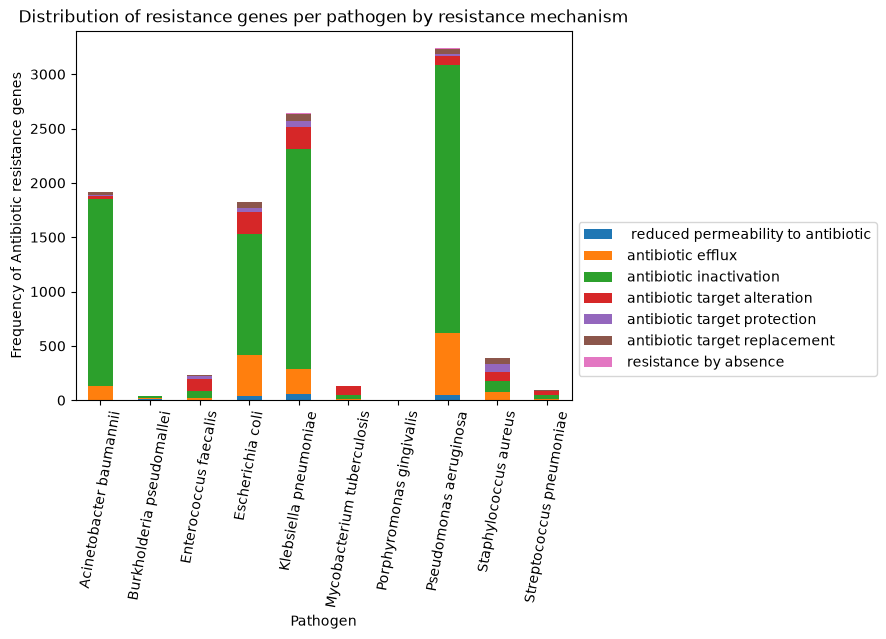

In [36]:
arg_pathogen_by_res_mech.plot.bar(stacked = True,rot = 80, ylabel = 'Frequency of Antibiotic resistance genes', 
                                  title = 'Distribution of resistance genes per pathogen by resistance mechanism').legend(loc='upper left',bbox_to_anchor=(1.0, 0.5))

<Axes: title={'center': 'Distribution of resistance genes per drug class'}, xlabel='Frequency of Antibiotic resistance genes', ylabel='Antibiotic drug class'>

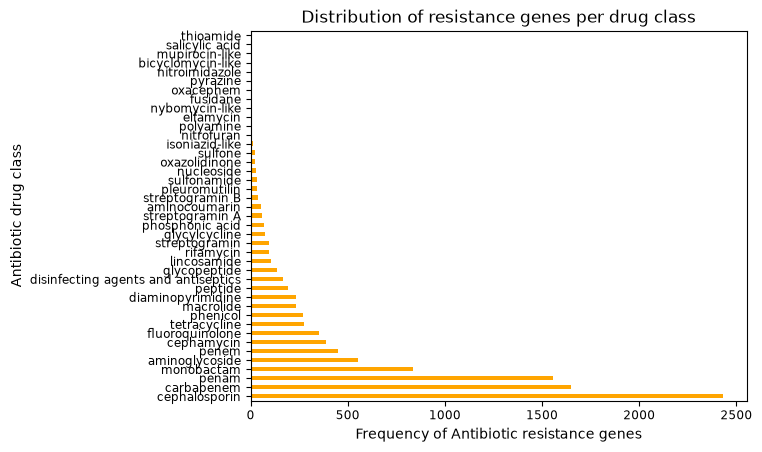

In [37]:
freq_drug_class = data_amr_poi2['Drug_Class'].value_counts()
freq_drug_class.plot.barh(title = 'Distribution of resistance genes per drug class', xlabel = 'Frequency of Antibiotic resistance genes', ylabel = 'Antibiotic drug class', color = 'orange',
                          fontsize = 8.5)